                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews   

                  date  label  
0    February 13, 2017      0  
1       April 5, 2017       1  
2  September 27, 2017       1  
3         May 22, 2017      0  
4       June 24, 2016       1  
label
0    23481
1    21417
Name: count, dtype: in

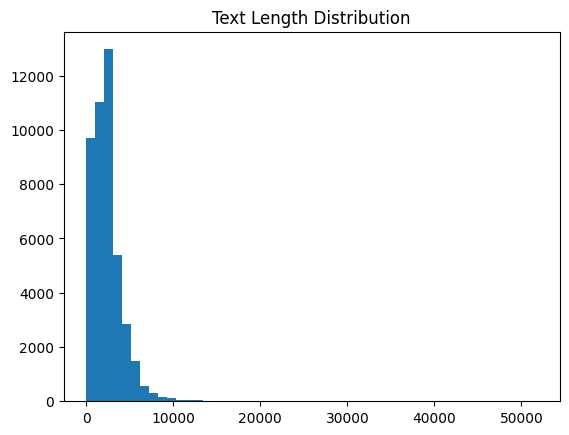

title          0
text           0
subject        0
date           0
label          0
text_length    0
dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as pl
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import torch
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader

# Load data (FIXED)
fake = pd.read_csv("/content/Fake.csv", engine="python", on_bad_lines="skip")
real = pd.read_csv("/content/True 2.csv", engine="python", on_bad_lines="skip")

# Add labels
fake["label"] = 0
real["label"] = 1

# Combine
df = pd.concat([fake, real], axis=0)

# Shuffle
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.head())
print(df["label"].value_counts())

# Clean text
df = df.dropna(subset=["text"])
df["text"] = df["text"].astype(str)

# Text length
df["text_length"] = df["text"].apply(len)

pl.hist(df["text_length"], bins=50)
pl.title("Text Length Distribution")
pl.show()

# Missing values
print(df.isnull().sum())

In [ ]:
# Combine title + text
df["content"] = df["title"] + " " + df["text"]

# Text cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df["content"] = df["content"].apply(clean_text)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    df["content"], df["label"], test_size=0.2, random_state=42
)

# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Model
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

# Predictions
y_pred = model.predict(X_test_tfidf)

# Metrics
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", acc)
print("F1-score:", f1)

Accuracy: 0.987305122494432
F1-score: 0.986703988803359


In [ ]:
df = pd.concat([fake, real], axis=0)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df = df.dropna(subset=["text"])

# Combine text
df["content"] = df["title"] + " " + df["text"]

# Clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df["content"] = df["content"].apply(clean_text)

# Tokenization (simple)
from collections import Counter

words = []
for text in df["content"]:
    words.extend(text.split())

vocab = {word: i+1 for i, (word, _) in enumerate(Counter(words).most_common(10000))}

def encode(text):
    return [vocab.get(word, 0) for word in text.split()]

df["encoded"] = df["content"].apply(encode)

# Padding
max_len = 200

def pad(seq):
    return seq[:max_len] + [0]*(max_len - len(seq)) if len(seq) < max_len else seq[:max_len]

df["padded"] = df["encoded"].apply(pad)

# Split
X = list(df["padded"])
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Dataset class
class NewsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(NewsDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(NewsDataset(X_test, y_test), batch_size=64)

# Model
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        x = self.embedding(x)
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

model = LSTMModel(len(vocab)+1, 64, 128)

# Training
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(3):
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 314.6420
Epoch 2, Loss: 211.2903
Epoch 3, Loss: 53.3361


In [ ]:
from sklearn.metrics import accuracy_score

model.eval()
preds = []
true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        predicted = torch.argmax(outputs, dim=1)
        preds.extend(predicted.numpy())
        true.extend(y_batch.numpy())

print("Accuracy:", accuracy_score(true, preds))

Accuracy: 0.984521158129176


In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        x = self.embedding(x)
        _, (h, _) = self.lstm(x)
        x = self.dropout(h[-1])
        return self.fc(x)

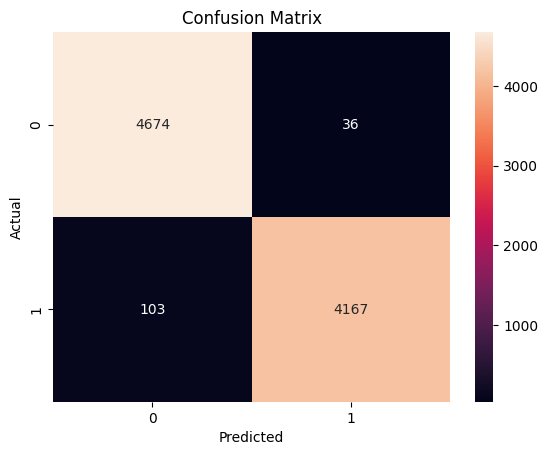

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true, preds)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()